In [59]:
import json
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
dataset_dir = f'{parent_dir}/dataset'

with open(f'{dataset_dir}/filled/tracks_filled_new_ids.json') as f:
    tracks = json.load(f)

In [60]:
tracks[0]

{'id': 'TR934808',
 'id_artist': 'ART04205421',
 'title': '\u200bpolka 2 :-/',
 'featured_artists': 'Ernia, Guè',
 'primary_artist': 'Rosa Chemical',
 'language': 'pl',
 'album': 'FOREVER AND EVER',
 'swear_IT': 13,
 'swear_EN': 6,
 'swear_IT_words': "['cazzo', 'cesso', 'coglioni', 'figa', 'merda', 'palle', 'piscio', 'porca', 'stronzo']",
 'swear_EN_words': "['bitch', 'fuck', 'porno', 'pussy']",
 'year': 2021.0,
 'month': 4.0,
 'day': 2.0,
 'n_sentences': 102.0,
 'n_tokens': 911.0,
 'char_per_tok': 4.1704545455,
 'avg_token_per_clause': 8.1339285714,
 'bpm': 135.32,
 'rolloff': 2895.7767,
 'flux': 1.4499,
 'rms': 0.1786,
 'flatness': 0.8202,
 'spectral_complexity': 25.7148,
 'pitch': 2311.1779,
 'loudness': 17.8675,
 'album_name': 'FOREVER AND EVER',
 'album_release_date': '2021-04-09',
 'album_type': 'album',
 'disc_number': 1.0,
 'track_number': 3.0,
 'duration_ms': 207761.0,
 'explicit': True,
 'popularity': 46.0,
 'id_album': 'ALB115557',
 'lyrics': 'Oplà, ah\nBdope, chiama due b—\

In [61]:
texts = list()

for track in tracks:
    texts.append(track['lyrics'])

In [62]:
count = 0
for i in range(len(texts)):
    if not texts[i]:
        count += 1
        texts[i] = ''

count

3

In [63]:
len(texts)

11166

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
dtm = vectorizer.fit_transform(texts)

num_topics = 20
nmf_model = NMF(n_components=num_topics, random_state=1)
nmf_model.fit(dtm)

topic_vectors = nmf_model.components_

/Users/brunobarbieri/Documents/Uni/master/second/first_sem/dss/lab/dsslab_venv/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [65]:
W = nmf_model.transform(dtm)

W

array([[1.38307499e-02, 4.50462702e-02, 2.68323593e-04, ...,
        7.61538135e-03, 2.81319396e-02, 9.74364266e-03],
       [0.00000000e+00, 2.60124392e-02, 3.15680906e-03, ...,
        0.00000000e+00, 2.26762907e-03, 9.13224384e-03],
       [0.00000000e+00, 9.53727312e-03, 9.16700147e-04, ...,
        1.55985101e-03, 0.00000000e+00, 0.00000000e+00],
       ...,
       [5.62784205e-03, 0.00000000e+00, 1.40772910e-04, ...,
        5.11921556e-03, 4.42578422e-05, 1.51347239e-03],
       [1.35225605e-02, 0.00000000e+00, 0.00000000e+00, ...,
        2.53298154e-02, 9.13250777e-04, 2.34835268e-02],
       [1.17419594e-03, 1.71822739e-04, 0.00000000e+00, ...,
        2.04389154e-03, 6.61106102e-04, 7.07519981e-04]],
      shape=(11166, 20))

In [66]:
tracks[0].keys()

dict_keys(['id', 'id_artist', 'title', 'featured_artists', 'primary_artist', 'language', 'album', 'swear_IT', 'swear_EN', 'swear_IT_words', 'swear_EN_words', 'year', 'month', 'day', 'n_sentences', 'n_tokens', 'char_per_tok', 'avg_token_per_clause', 'bpm', 'rolloff', 'flux', 'rms', 'flatness', 'spectral_complexity', 'pitch', 'loudness', 'album_name', 'album_release_date', 'album_type', 'disc_number', 'track_number', 'duration_ms', 'explicit', 'popularity', 'id_album', 'lyrics', 'streams@1month', 'new_id_album', 'new_track_id', 'new_id_artist'])

In [67]:
count = 0

for track in tracks:
    if (track.get('n_sentences') and track.get('lyrics')):
        if track['n_sentences'] >= len(track['lyrics'].split('\n')) - 10 and track['n_sentences'] <= len(track['lyrics'].split('\n')) + 10:
            count += 1

count

10864

In [68]:
for track in tracks:
    if not track.get('n_sentences') and track.get('lyrics'):
        track['n_sentences'] = len(track['lyrics'].split('\n'))
    elif not track.get('n_sentences') and not track.get('lyrics'):
        track['n_sentences'] = 0

In [69]:
count = 0

for track in tracks:
    if not track.get('bpm'):
        count += 1
        
count

64

In [70]:
# fill bpm, duration_ms with median
import statistics

def set_missing_to_median(field):
    values = []

    for track in tracks:
        if track.get(field):
            track[field] = float(track[field])
            values.append(float(track[field]))

    median = statistics.median(values)

    for track in tracks:
        if not track.get(field):
            track[field] = median

set_missing_to_median('bpm')
set_missing_to_median('duration_ms')

In [71]:
# fill missing popularity with 0
for track in tracks:
    if not track.get('popularity'):
        track['popularity'] = 0

# Clustering

In [72]:
from sklearn.preprocessing import StandardScaler
# W is your original Document-Topic Matrix
scaler = StandardScaler()
W = scaler.fit_transform(W)

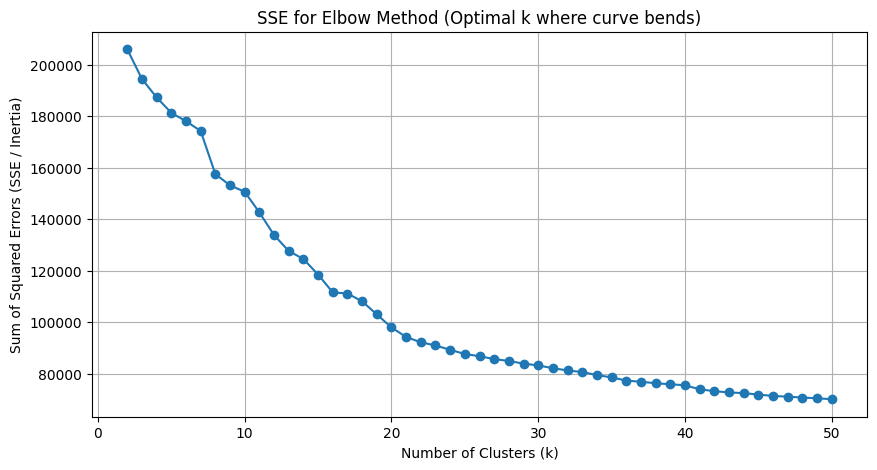

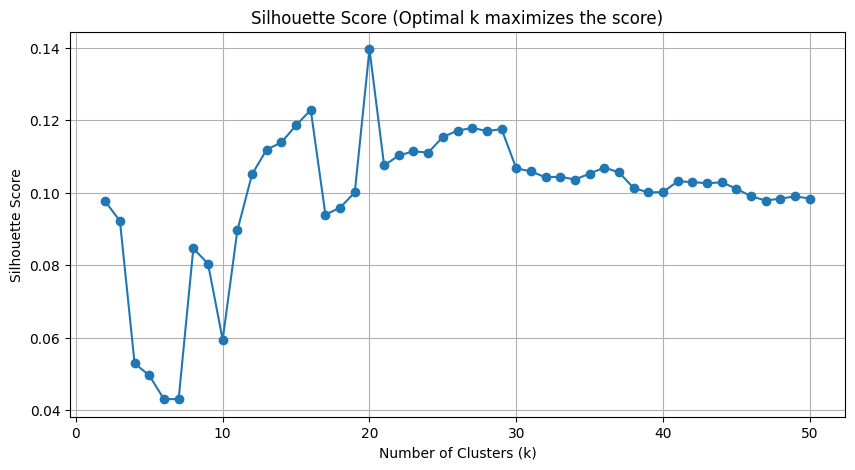

In [73]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

sse_list = []
silhouette_list = []

k_range = range (2, 51)


for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(W)
    
    sse_list.append(kmeans.inertia_)
    
    score = silhouette_score(W, kmeans.labels_)
    silhouette_list.append(score)
    
# SSE
plt.figure(figsize=(10, 5))
plt.plot(k_range, sse_list, marker='o')
plt.title('SSE for Elbow Method (Optimal k where curve bends)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE / Inertia)')
plt.grid(True)
plt.show()

# Silhouette Score
plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_list, marker='o')
plt.title('Silhouette Score (Optimal k maximizes the score)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [74]:
k = 8

kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
kmeans.fit(W)

topic_labels = kmeans.labels_

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

W_pca = pca.fit_transform(W)

df_pca = pd.DataFrame(data=W_pca, columns=['PC1', 'PC2'])

df_pca['Cluster'] = topic_labels

explained_variance = pca.explained_variance_ratio_.sum()

print(f"PCA reduced the data from 20 dimensions to 2.")
print(f"Total variance explained by these two components: {explained_variance:.2%}")
print("\nDataFrame ready for plotting:")
print(df_pca.head())

PCA reduced the data from 20 dimensions to 2.
Total variance explained by these two components: 19.99%

DataFrame ready for plotting:
        PC1       PC2  Cluster
0 -1.528997  1.049609        6
1 -2.522462  0.214434        5
2 -2.935163  2.611206        6
3 -1.058432  1.055631        0
4 -3.031591  3.495490        6


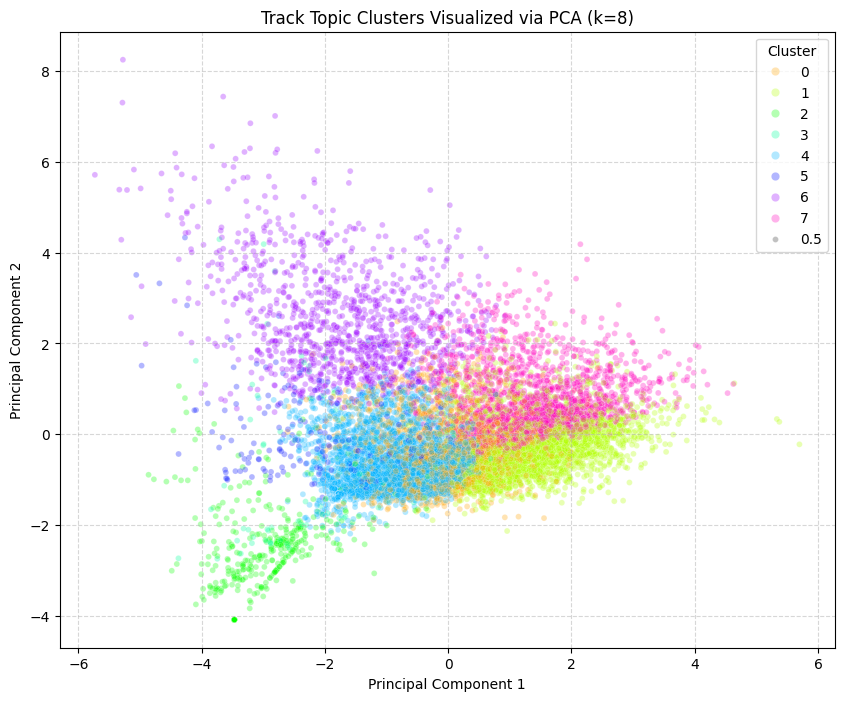

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Use seaborn to create a scatter plot, using the 'Cluster' column to assign colors
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    data=df_pca, 
    palette=sns.color_palette("hsv", n_colors=len(np.unique(topic_labels))), # Ensure distinct colors
    legend="full",
    alpha=0.3 ,
    size=0.5
)

plt.title(f'Track Topic Clusters Visualized via PCA (k={len(np.unique(topic_labels))})')
plt.xlabel(f'Principal Component 1')
plt.ylabel(f'Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('pca_cluster_visualization.png')
plt.show()

In [77]:
clusters = [[], [], [], [], [], [], [], []]

for track, topic in zip (tracks, topic_labels):
    if topic == 0.5:
        print(track)
    else:
        clusters[topic].append(track)

In [78]:
max_streams = 0

for track in tracks:
    if track['streams@1month'] > max_streams:
        max_streams = track['streams@1month']
        
max_streams

1501925.0

In [79]:
for cluster in clusters:
    print(len(cluster))

1953
2573
369
81
3051
182
1138
1819


Cluster 0 avg streams@1month:		16223.719406041986
	Standard Deviation:		33590.44766466533

Cluster 1 avg streams@1month:		14083.575592693354
	Standard Deviation:		29002.17937455346

Cluster 2 avg streams@1month:		18401.921409214094
	Standard Deviation:		33211.879553724284

Cluster 3 avg streams@1month:		16487.53086419753
	Standard Deviation:		20985.511568750488

Cluster 4 avg streams@1month:		15205.155031137332
	Standard Deviation:		33981.98379732795

Cluster 5 avg streams@1month:		40634.46703296703
	Standard Deviation:		49439.69288094224

Cluster 6 avg streams@1month:		34314.0158172232
	Standard Deviation:		68512.93412514155

Cluster 7 avg streams@1month:		18983.852116547554
	Standard Deviation:		36591.69715851076



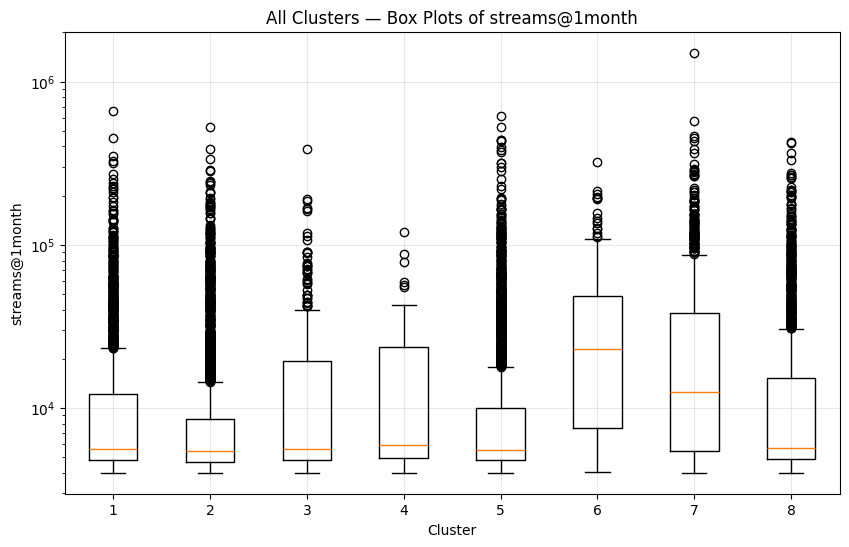

In [84]:
from statistics import mean, stdev
import numpy as np
import matplotlib.pyplot as plt

# Collect data in one structure for the combined plot
all_stream_distributions = []

for cluster in range(len(clusters)):
    streams = [track['streams@1month'] for track in clusters[cluster]]
    all_stream_distributions.append(streams)

    print(f'Cluster {cluster} avg streams@1month:\t\t{mean(streams)}')
    print(f'\tStandard Deviation:\t\t{stdev(streams)}\n')

# ---- Combined Box Plot ----
plt.figure(figsize=(10, 6))
plt.boxplot(all_stream_distributions, vert=True, showfliers=True)

plt.title("All Clusters — Box Plots of streams@1month")
plt.xlabel("Cluster")
plt.ylabel("streams@1month")
plt.grid(alpha=0.3)

plt.yscale('log')
plt.show()
